# Train emulator

## AKSGP vs DistPC-AKSGP -------> AKSGP wins! For both Grad and CE!


In [1]:
import os, sys, json
import numpy as np
from pathlib import Path
import gzip, dill
import matplotlib.pyplot as plt
import seaborn as sns

src_dir = os.path.abspath(os.path.join(os.getcwd(), "../../../../..", "src"))
sys.path.append(src_dir)
from plot_scripts import setup_rc_params
setup_rc_params(fontsize=13)

aksgp_dir = os.path.abspath(os.path.join(os.getcwd(), "../.."))
sys.path.append(aksgp_dir)

from AKSGP import Emulator as AKSGP_emu

# ----------------------------------
exp_save_dir = Path("../../../experimental_data")
# load bins from file
bin_file = json.loads(Path(f"{exp_save_dir}/PbPb2760_bins.json").read_text())
bins = {k: np.array(item["data"], dtype=item["dtype"]) for k, item in bin_file.items()}
active_obs = list(bins.keys())
counts_per_obs = {k: v.shape[0] for k, v in bins.items()}

# ----------------------------------


In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

obs_labels = {
    'dNch_deta'      : r'$dN_{ch}/d\eta$',
    'dET_deta'       : r'$dE_T/d\eta$',
    'dN_dy_pion'     : r'$dN_{\pi}/dy$',
    'dN_dy_kaon'     : r'$dN_{k}/dy$',
    'dN_dy_proton'   : r'$dN_{p}/dy$',
    'mean_pT_pion'   : r'$\langle p_T \rangle_{\pi}$',
    'mean_pT_kaon'   : r'$\langle p_T \rangle_{k}$',
    'mean_pT_proton' : r'$\langle p_T \rangle_{p}$',
    'pT_fluct'       : r'$\delta p_T/\langle p_T \rangle$',
    'v22'            : r'$v_2\{2\}$',
    'v32'            : r'$v_3\{2\}$',
    'v42'            : r'$v_4\{2\}$'
}

def plot_err_grid(sim_mean, sim_std, gp_mean, gp_std, spans, active_obs, fig_path,
                  ncols=4, figsize_per_col=4.0, figsize_per_row=3.5):
    """
    sim_mean, sim_std, gp_mean, gp_std: arrays of shape (N, total_out)
    spans: dict {obs: slice} mapping each observable to its contiguous column span
    active_obs: list of observable names in the desired order
    fig_path: where to save (e.g. 'plots/grid_err.pdf')
    """

    n_obs  = len(active_obs)
    nrows  = 3
    ncols  = 4
    assert n_obs <= nrows*ncols, "Grid (3x4) holds up to 12 observables."

    fig, axes = plt.subplots(nrows, ncols, figsize=(ncols*figsize_per_col*0.8, nrows*figsize_per_row*0.8), sharex=False)
    
    # Plot each observable
    for i, obs in enumerate(active_obs):
        r, c = divmod(i, ncols)
        ax   = axes[r, c]
        sl   = spans[obs]

        x     = np.asarray(sim_mean[:, sl]).ravel()
        y     = np.asarray(gp_mean[:, sl]).ravel()
        xerr  = np.asarray(sim_std[:, sl]).ravel()
        yerr  = np.asarray(gp_std[:, sl]).ravel()

        ax.errorbar(x, y, xerr=xerr, yerr=yerr, fmt='none',
                    color='blue', elinewidth=0.6, capsize=1.0, capthick=0.4, alpha=0.35, zorder=1)

        # 1:1 line
        mn = float(np.nanmin([x.min(), y.min()]))
        mx = float(np.nanmax([x.max(), y.max()]))
        ax.plot([mn, mx], [mn, mx], linestyle='--', linewidth=1, color='red', zorder=3)

        ax.grid(alpha=0.3)
        ax.text(
            0.05, 0.95, obs_labels[obs],
            transform=ax.transAxes, ha="left", va="top", fontsize=13, fontweight="bold",
            bbox=dict(boxstyle="round,pad=0.25", facecolor="none", edgecolor="black", linewidth=0.8)
        )

        ax.set_xlabel("Model simulation")
        ax.set_ylabel("Emulator prediction")
        
        # # Labels only on left/bottom
        # if r == nrows - 1:
        #     ax.set_xlabel("Model simulation")
        # if c == 0:
        #     ax.set_ylabel("Emulator prediction")

    # Hide any unused panels
    for j in range(n_obs, nrows*ncols):
        r, c = divmod(j, ncols)
        axes[r, c].axis('off')

    fig.tight_layout()

    os.makedirs(os.path.dirname(fig_path) or ".", exist_ok=True)
    fig.savefig(fig_path, bbox_inches="tight", dpi=400)
    plt.show()


spans = {}
start = 0
for obs in active_obs:
    n = int(counts_per_obs[obs])      # how many columns this observable has
    spans[obs] = slice(start, start+n) # columns [start, start+n)
    start += n

total_out = start  # sum of all columns across observables

## Plot

<<========== Grad: train ==========>>


/var/folders/w7/ygz14_194fs1mqhvr0jwdcc80000gn/T/ipykernel_15496/1358853920.py:77: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


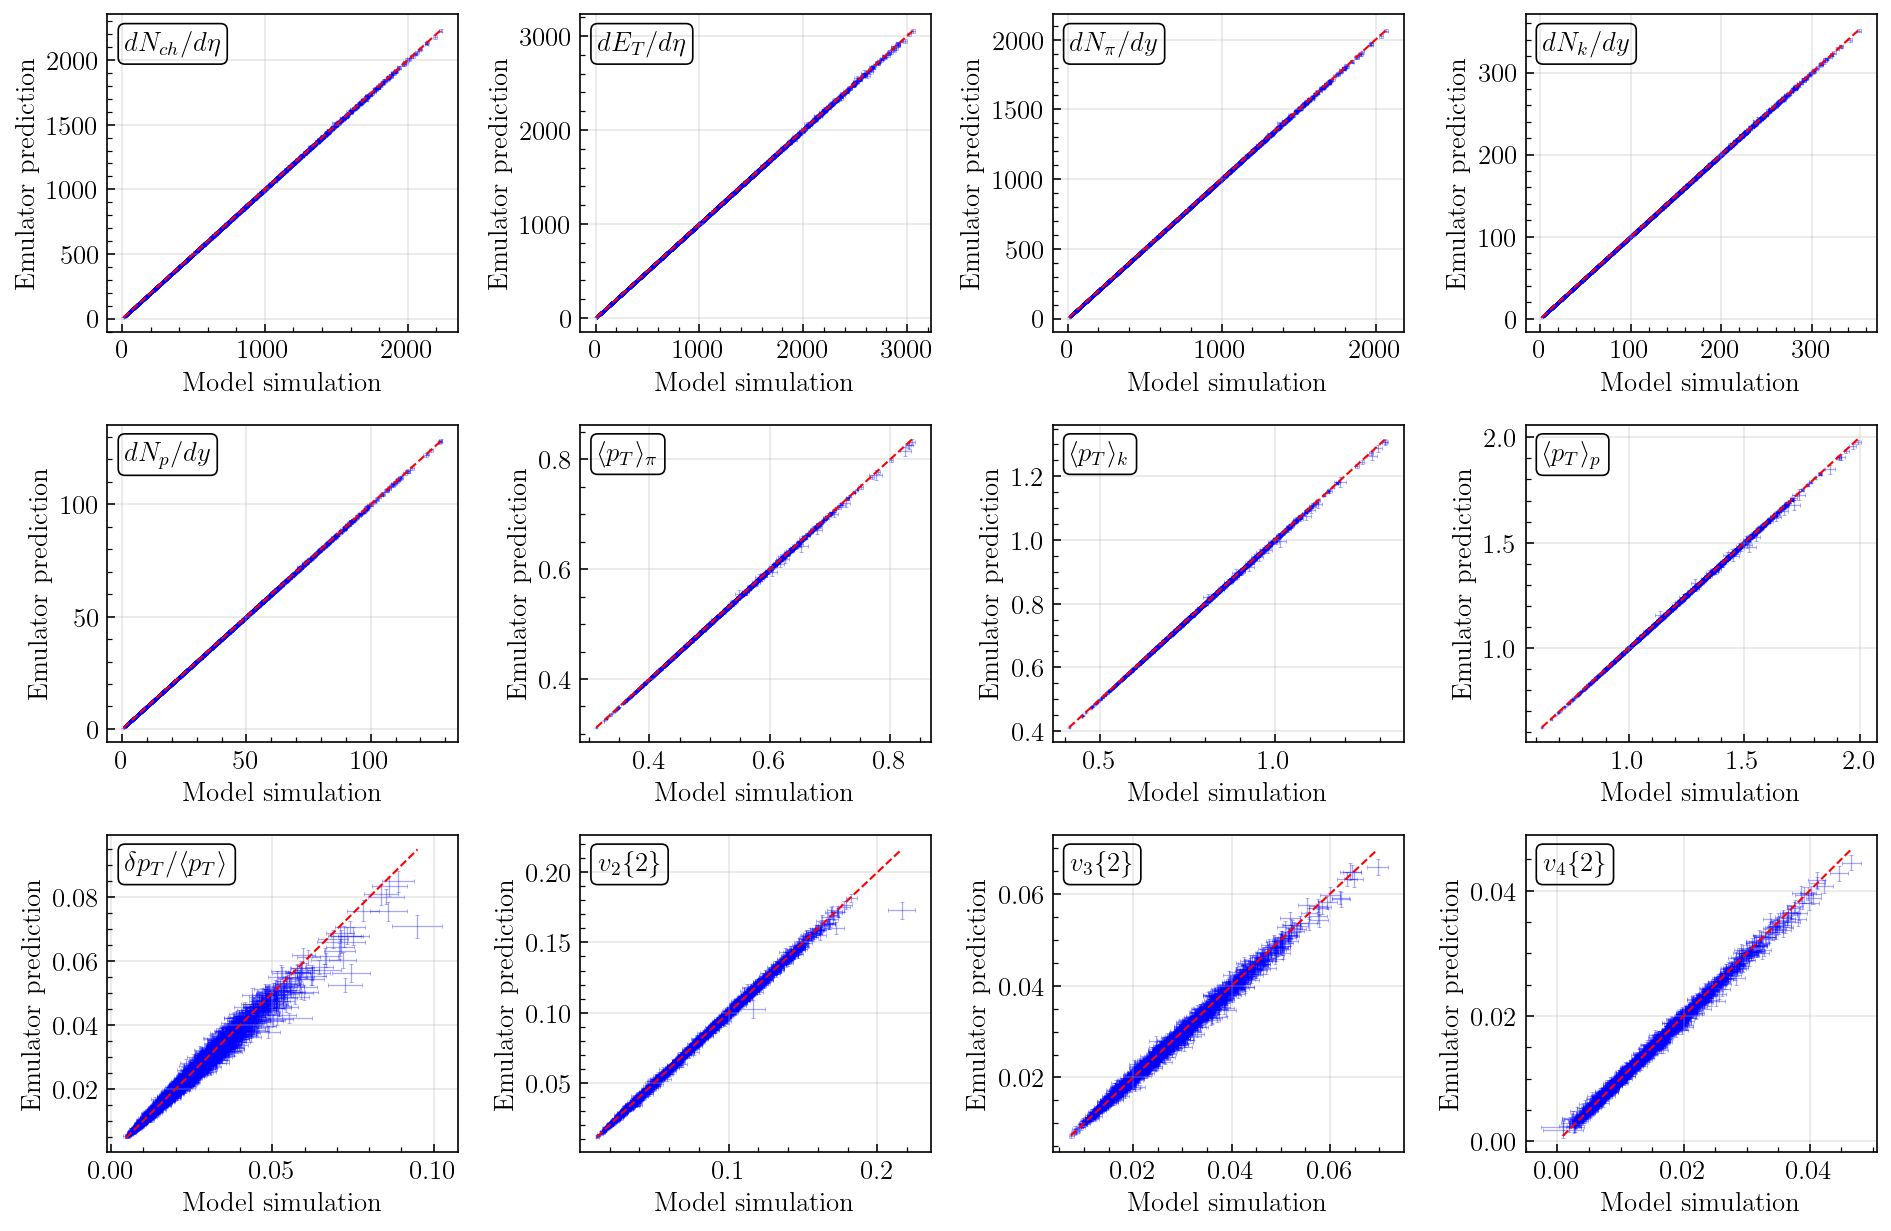

<<========== Grad: test ==========>>


/var/folders/w7/ygz14_194fs1mqhvr0jwdcc80000gn/T/ipykernel_15496/1358853920.py:77: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


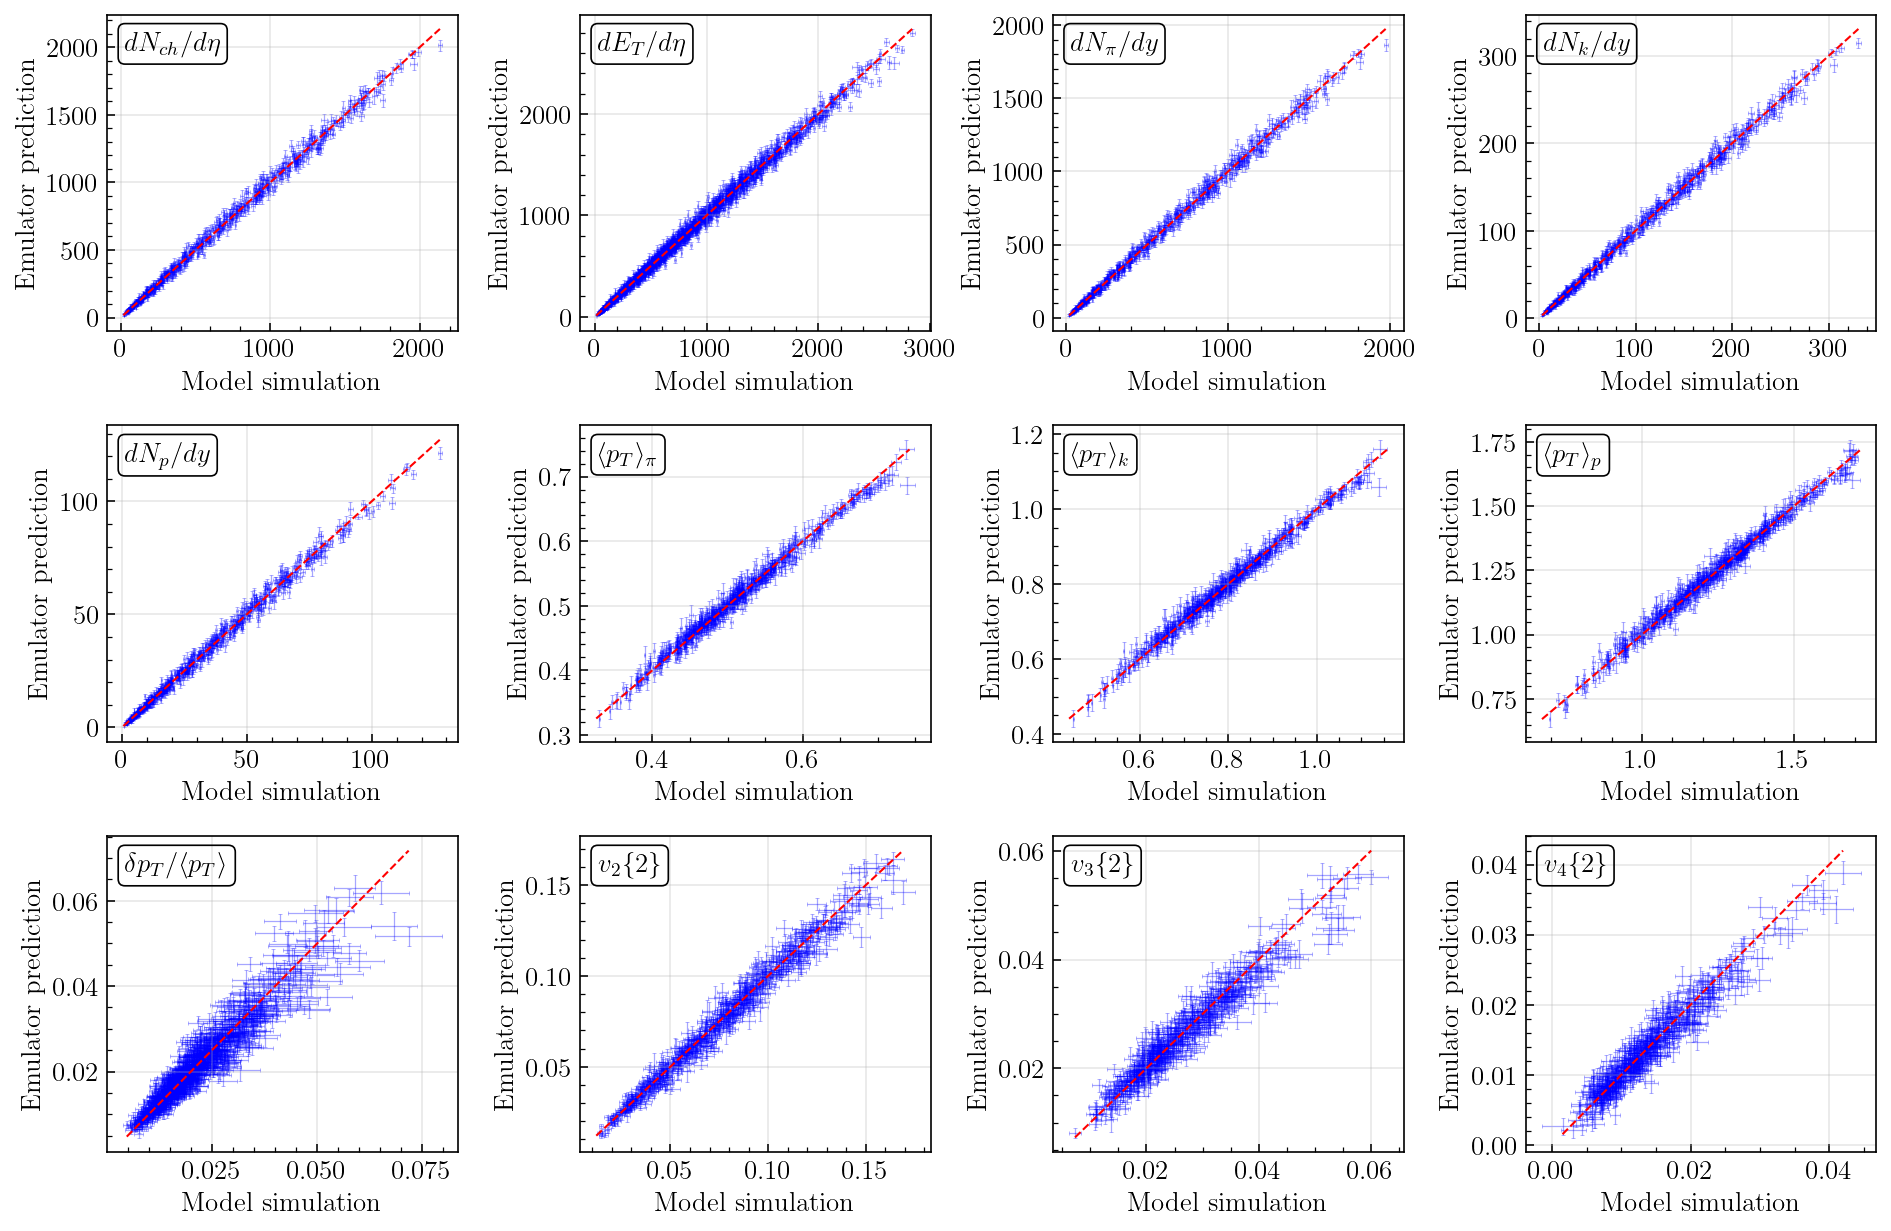

<<========== CE: train ==========>>


/var/folders/w7/ygz14_194fs1mqhvr0jwdcc80000gn/T/ipykernel_15496/1358853920.py:77: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


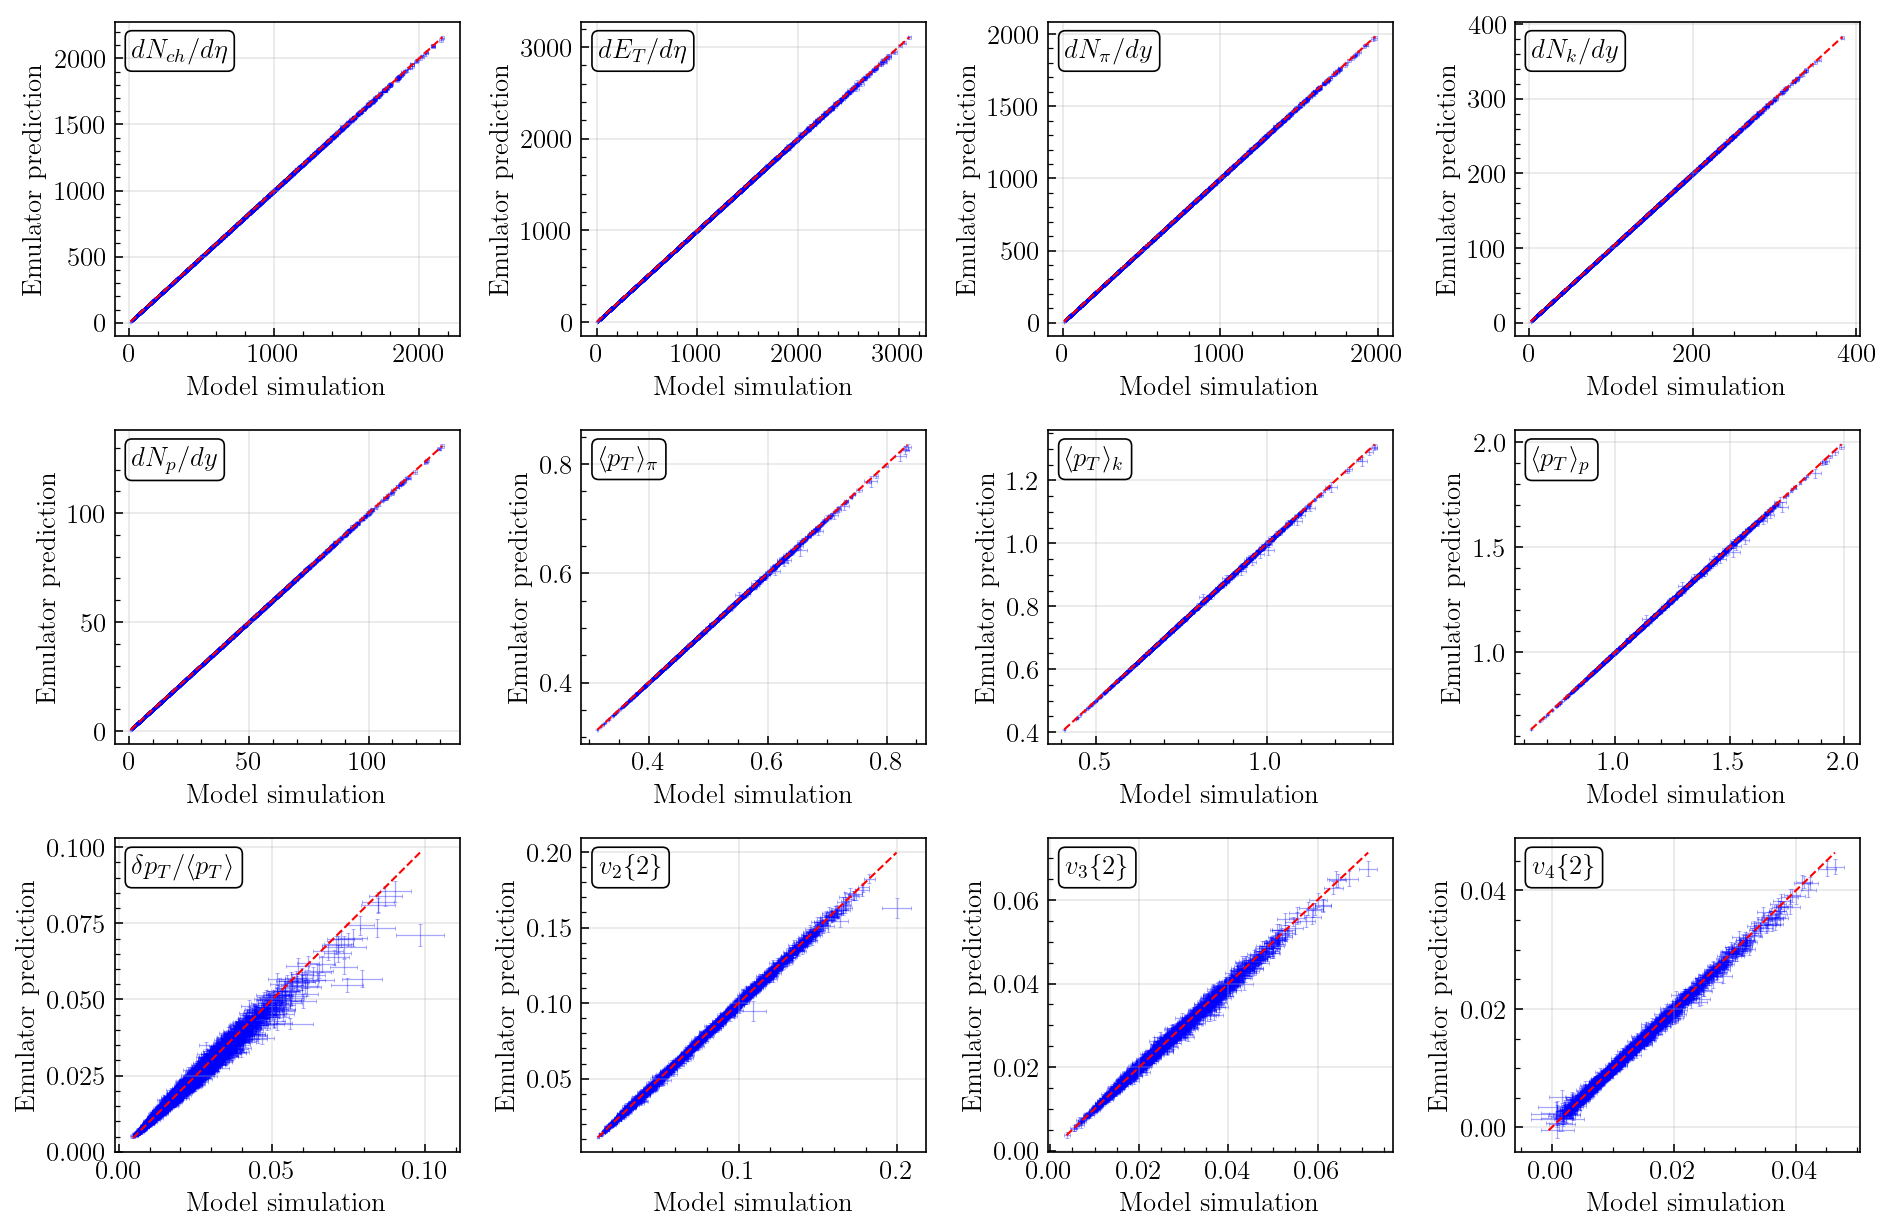

<<========== CE: test ==========>>


/var/folders/w7/ygz14_194fs1mqhvr0jwdcc80000gn/T/ipykernel_15496/1358853920.py:77: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


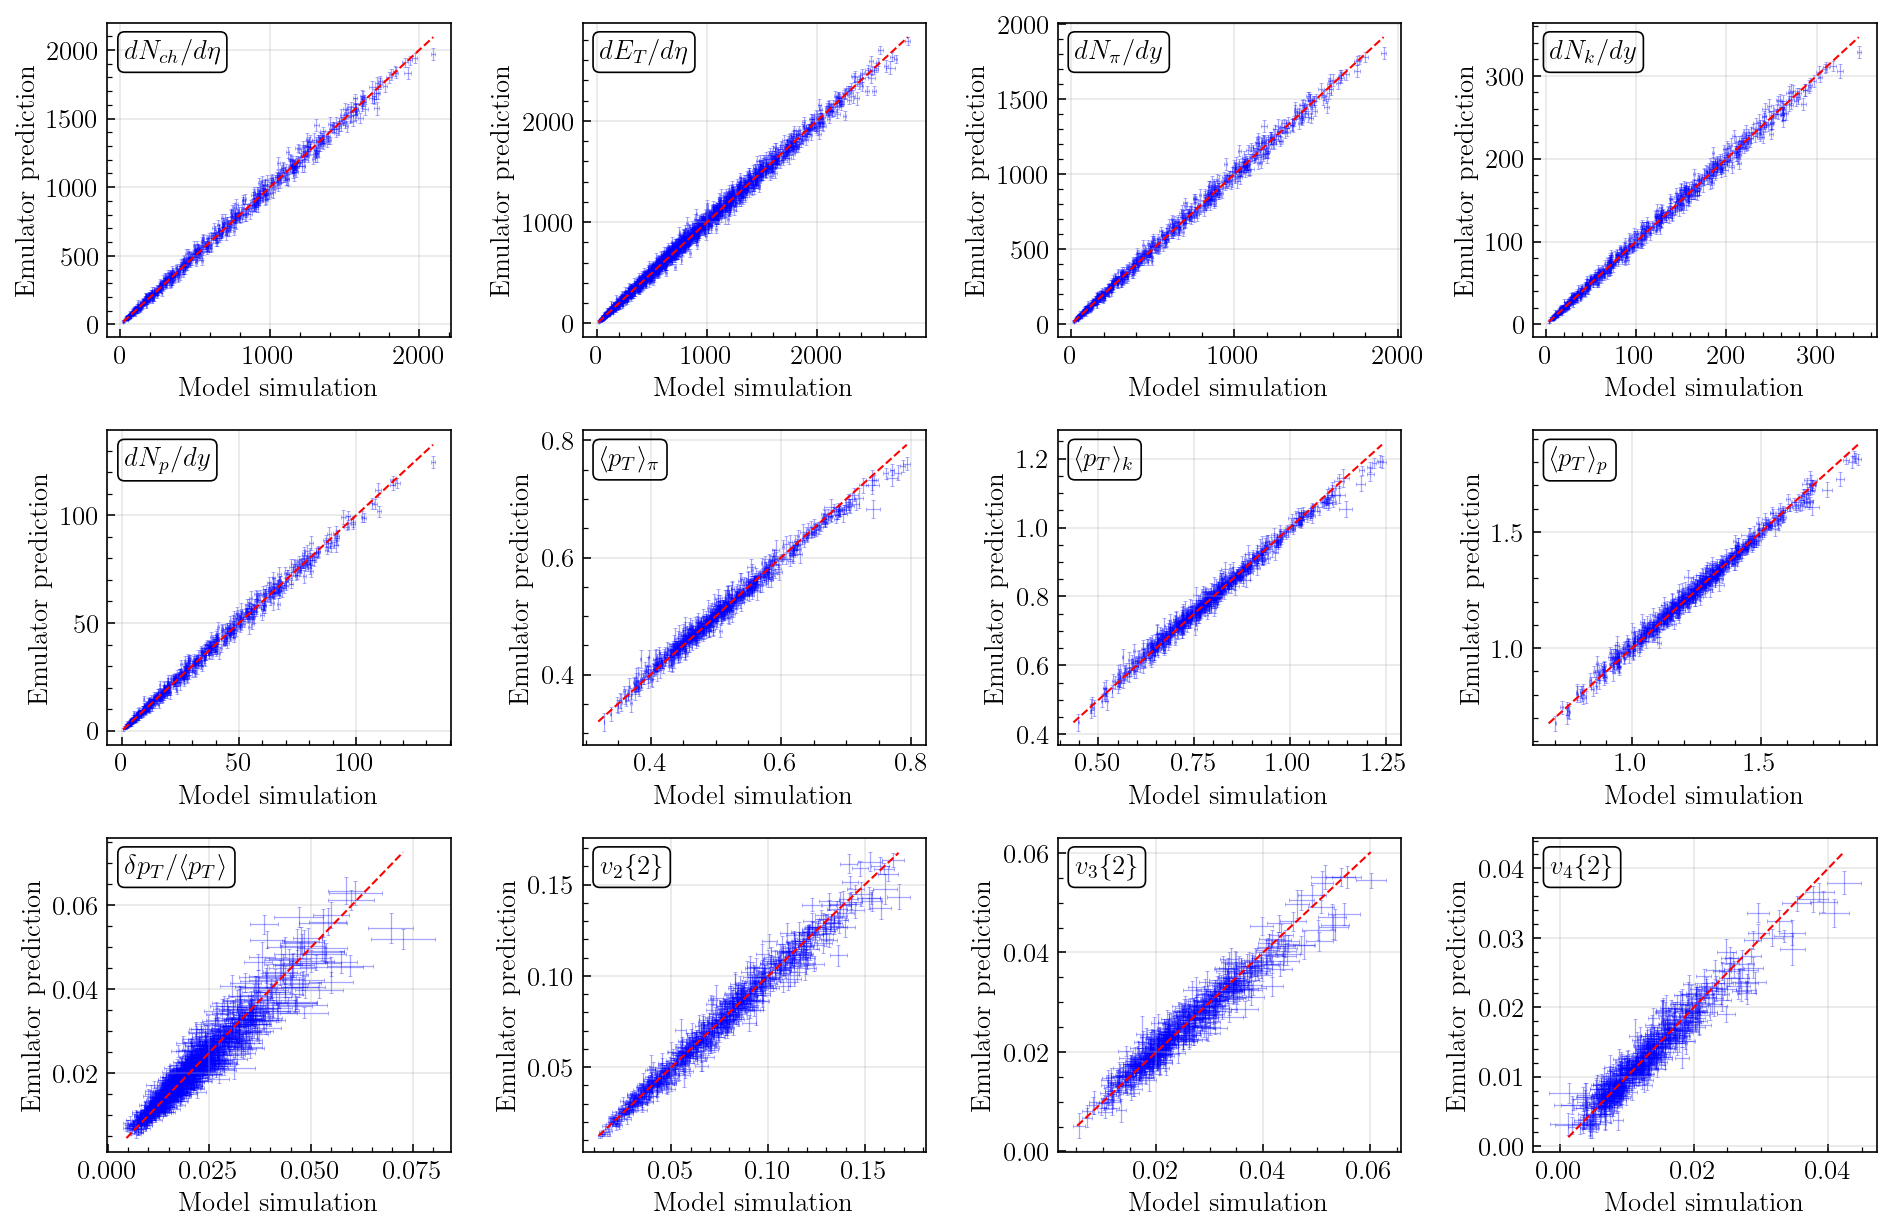

In [3]:
def plot_test_emu(idf, testortrain):
    print(f"<<========== {idf}: {testortrain} ==========>>")
    
    directory = f'simulation_data/{idf}/{testortrain}'
    X = np.loadtxt(os.path.join(directory, 'X.txt'))
    Ymean = np.loadtxt(os.path.join(directory, 'Ymean.txt'))
    Ystd = np.loadtxt(os.path.join(directory, 'Ystd.txt'))
    
    with gzip.open(f"../Emulator_AKSGP_{idf}.dill.gz", "rb") as f:
        emu = dill.load(f)
    
    gpm, gps = emu.predict(X)
    
    plot_err_grid(sim_mean=Ymean, sim_std=Ystd, gp_mean=gpm, gp_std=gps,
                  spans=spans,
                  active_obs=active_obs,
                  fig_path=f"plots/AKSGP_{idf}_{testortrain}.pdf")


# idf = 'Grad' # 'Grad' 'CE'
# testortrain = 'test' # 'test' 'train'

plot_test_emu(idf='Grad', testortrain='train')
plot_test_emu(idf='Grad', testortrain='test')
plot_test_emu(idf='CE', testortrain='train')
plot_test_emu(idf='CE', testortrain='test')
